In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from datetime import timedelta
from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.heat_pump import visualise_heat_pump_performance
from etl.product import show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap

import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 34,014 quotes from 23,888 customers


In [2]:
#customers = aggregate_customer(df_clean)

In [3]:
customers = pd.read_csv('customer_master_data.csv')


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.362042           17335           6276.0
True                      0.485579            6553           3182.0

Chi-square p-value: 7.601147e-68
Statistically significant: YES

Conversion without issues: 36.20%
Conversion with issues: 48.56%
Difference: 12.4 percentage points
Customer-level finding: +12.4 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.38
  With issues: 1.53
  Ratio: 1.11x

avg_quote_amount:
  No issues: 6164.43
  With issues: 9935.00
  Ratio: 1.61x

max_quote_amount:
  No issues: 6571.38
  With issues: 10832.75
  Ratio: 1.65x

customer_duration_days:
  No issues: 17.87
  With issues: 24.31
  Ratio: 1.36x

price_range:
  No issues: 868.91
  With issues: 1702.03
  Ratio: 1.96x

multiple_quotes:
  No issues: 

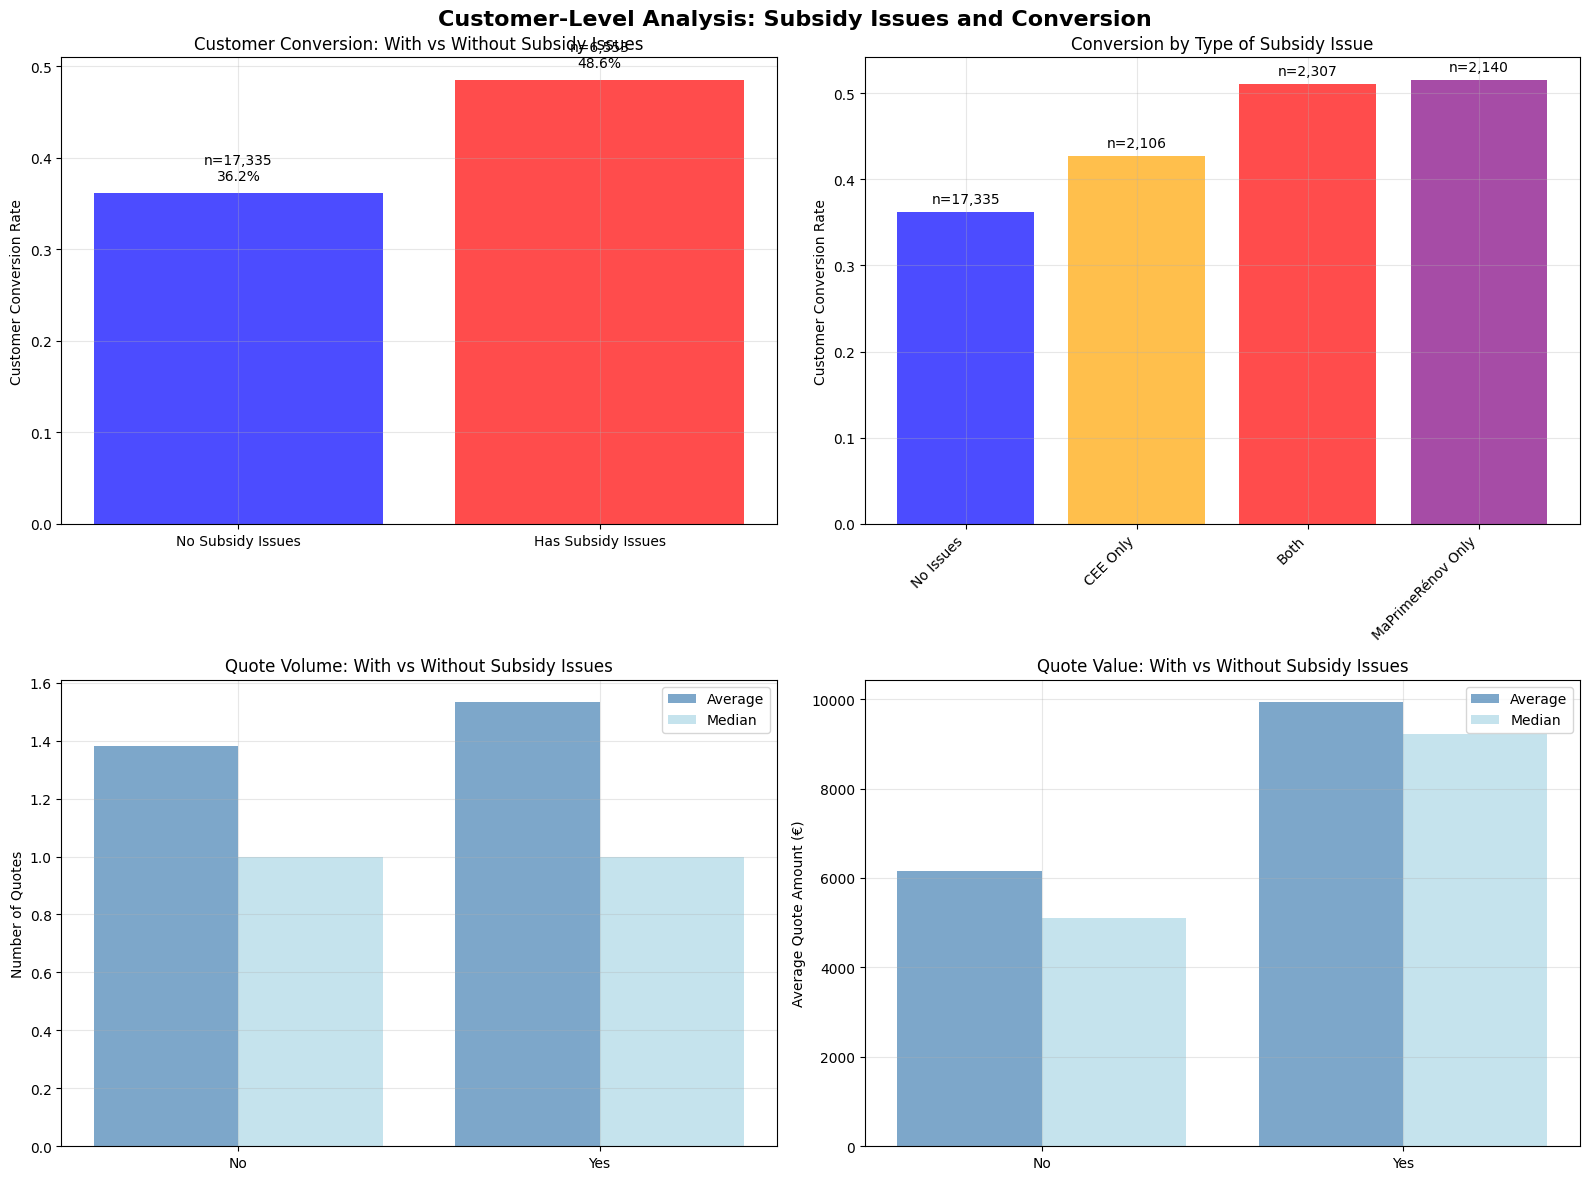


Policy suspension impact

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Conversion during subsidy suspensions:
                      mean  count
Normal Periods     0.40814  19361
During Suspension  0.31795   2947

Suspension impact p-value: 1.336461e-20
Statistically significant: YES

Product mix during suspensions:
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
during_suspension                                                      
False                    17.3    31.7       18.8    8.1   23.8      0.2
True                     38.0    28.1       10.6    6.2   17.1      0.0


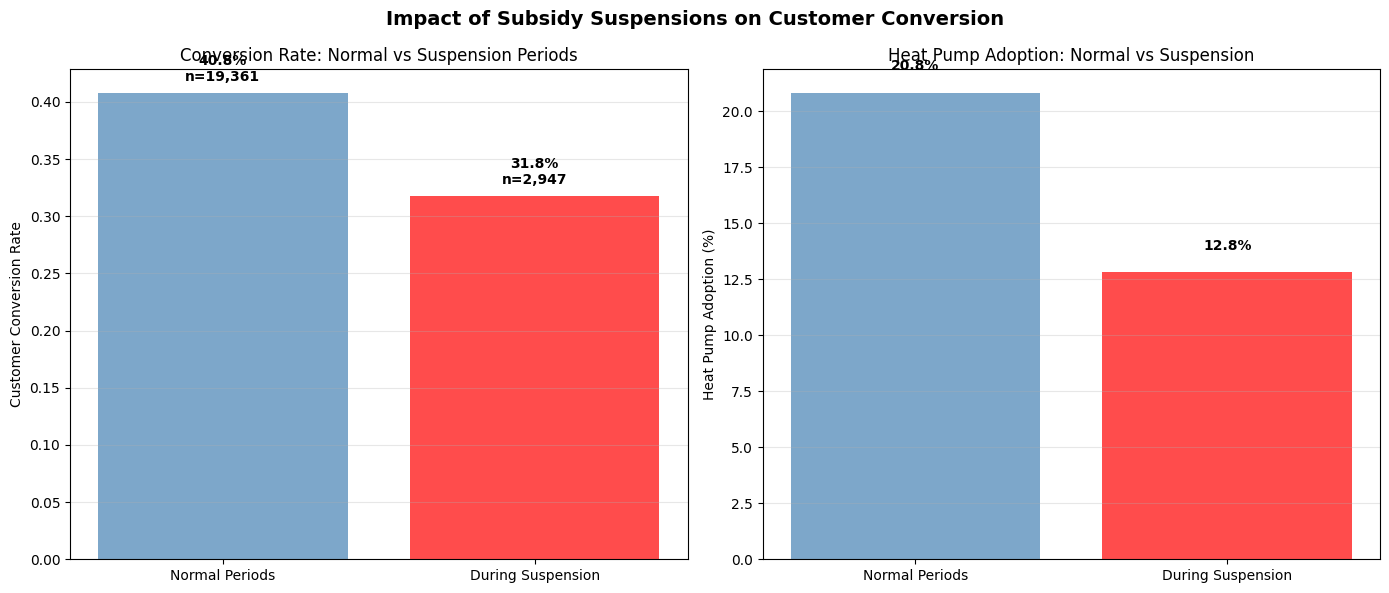

In [4]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

Unique values in main_product_family:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire                  103
Emetteur de chauffage  ou chappe      93
Produit VMC                           89
Unknown                               36
Fumisterie                            13
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire 

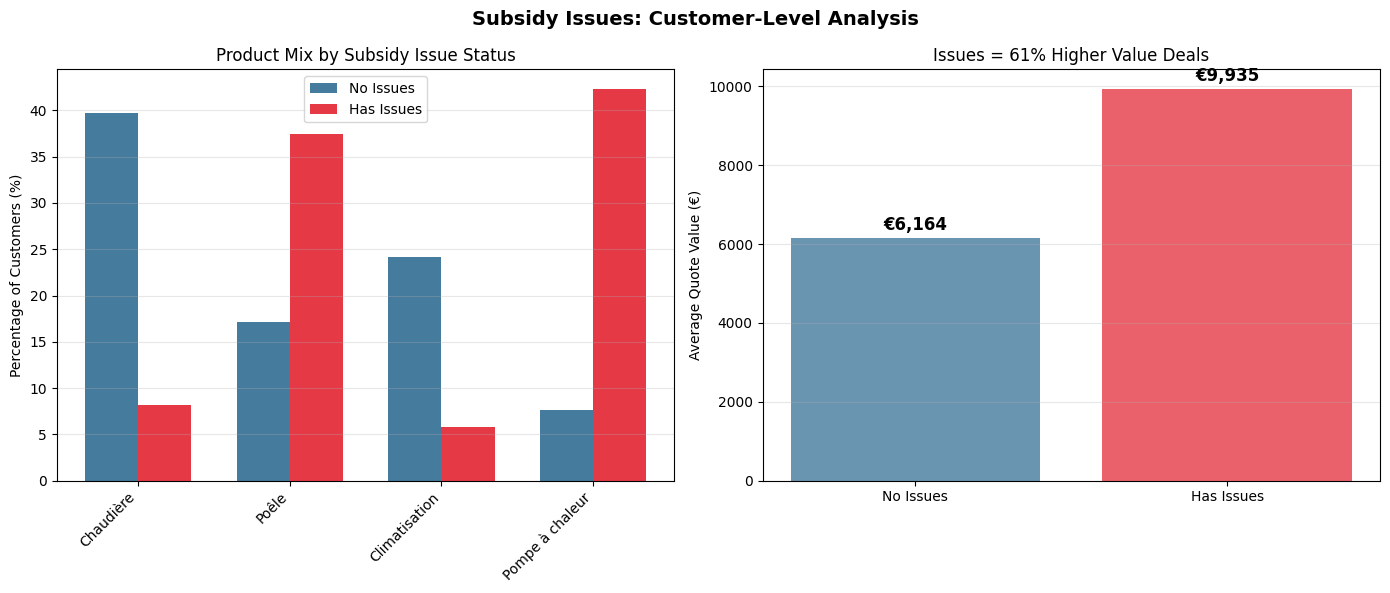

In [5]:
top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)


Threshold effect

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


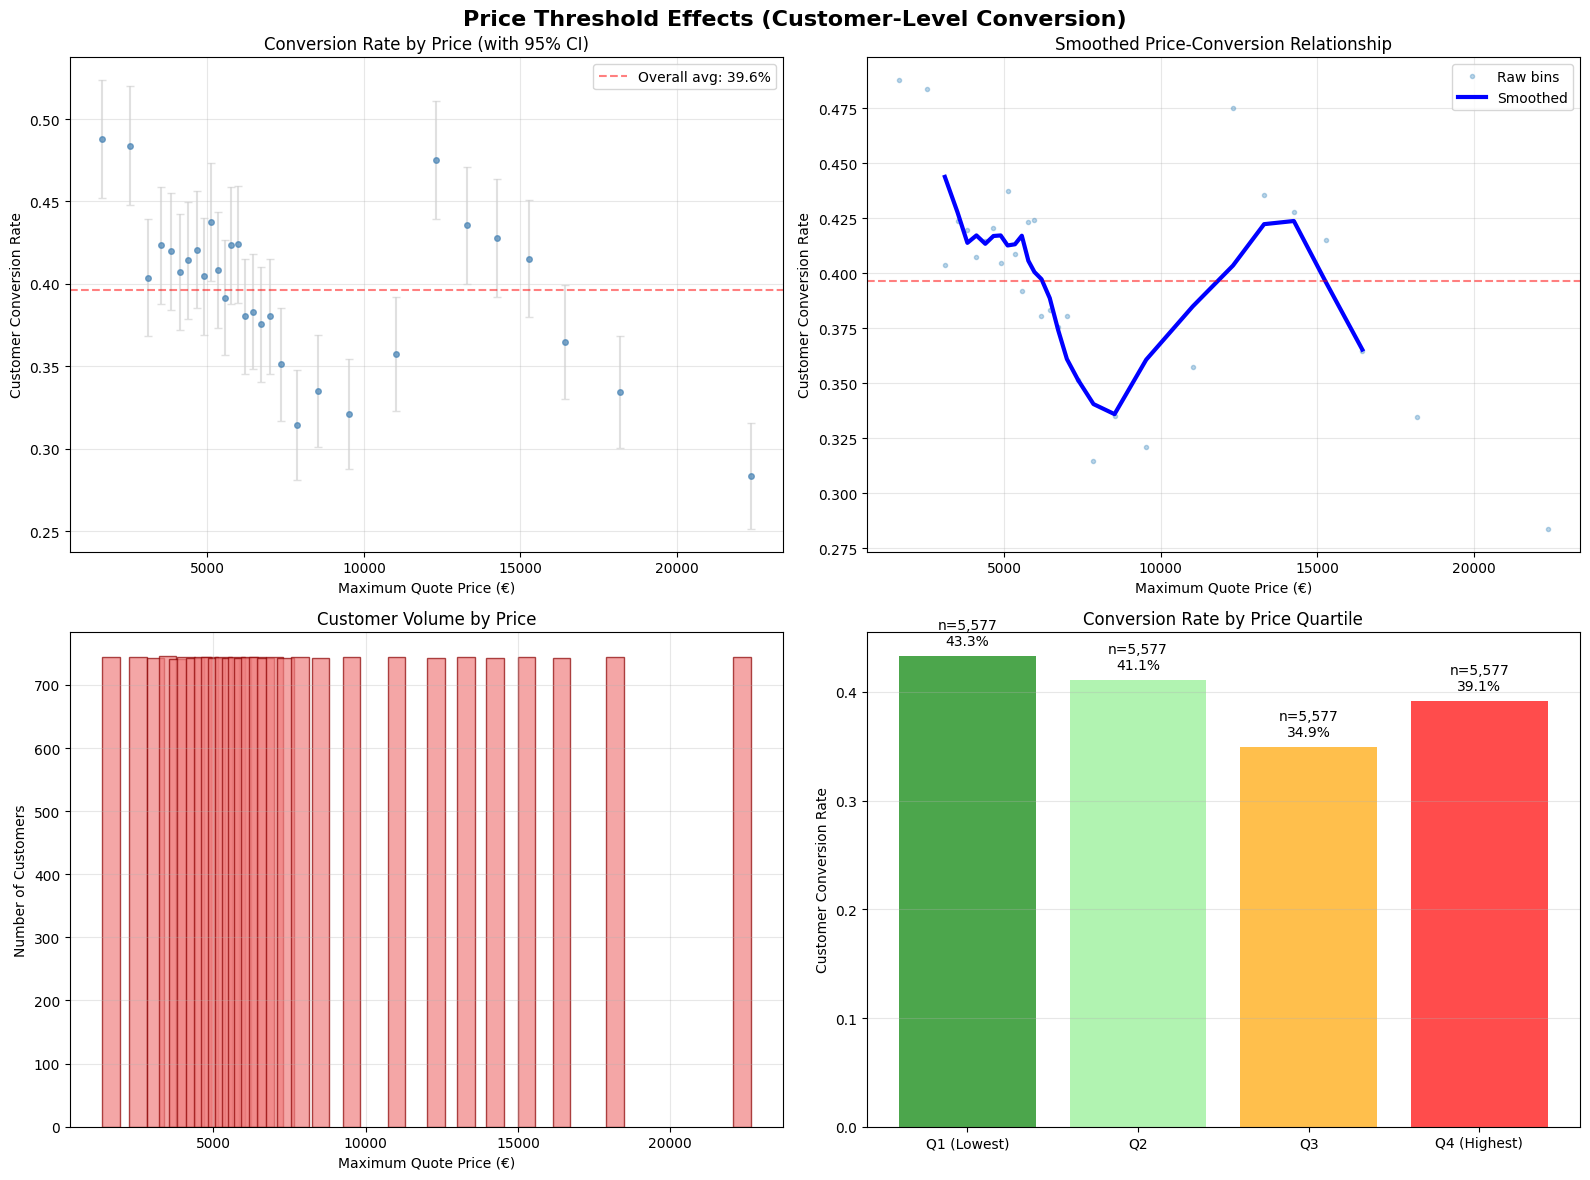


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 43.3% (n=5,577)
  Q2: 41.1% (n=5,577)
  Q3: 34.9% (n=5,577)
  Q4 (Highest): 39.1% (n=5,577)

Difference between lowest and highest quartile: 4.2 percentage points

Sweet spots (above-average conversion):
  €1,643: 48.8% (n=744)
  €2,523: 48.4% (n=744)
  €3,102: 40.4% (n=743)
  €3,506: 42.4% (n=746)
  €3,822: 42.0% (n=741)
  €4,110: 40.7% (n=744)
  €4,393: 41.4% (n=743)
  €4,654: 42.1% (n=744)
  €4,884: 40.5% (n=744)
  €5,107: 43.7% (n=743)
  €5,341: 40.9% (n=744)
  €5,769: 42.3% (n=744)
  €5,963: 42.4% (n=743)
  €12,305: 47.5% (n=743)
  €13,300: 43.5% (n=744)
  €14,250: 42.8% (n=743)
  €15,283: 41.5% (n=744)

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
price_quartile                                                         
Q1_Low

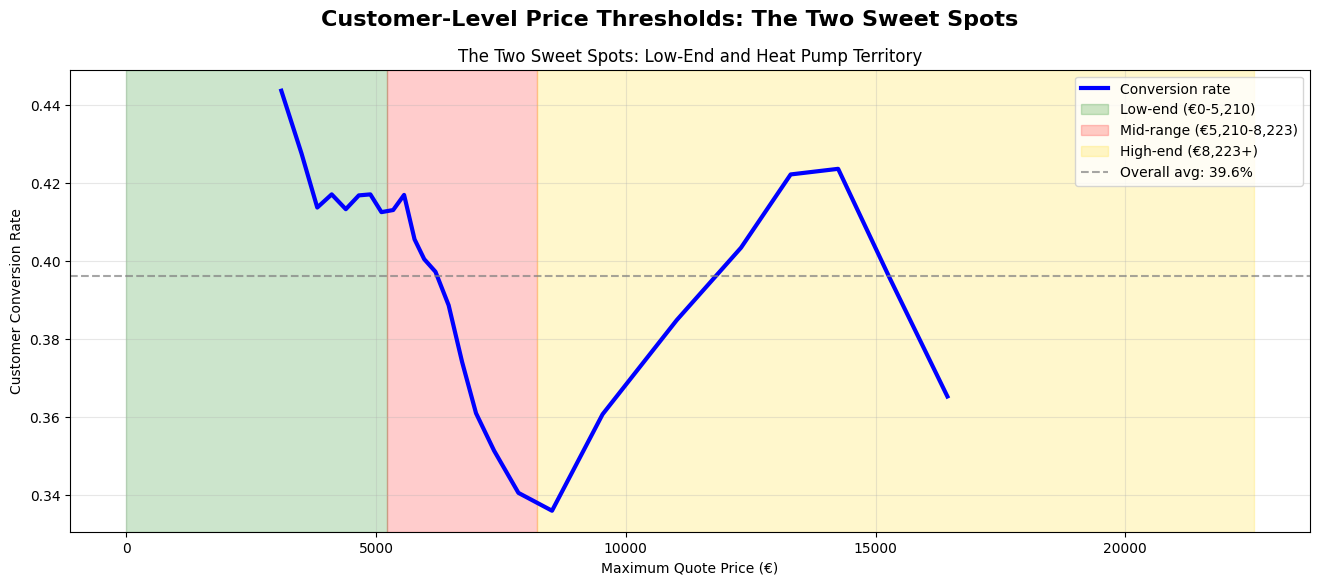

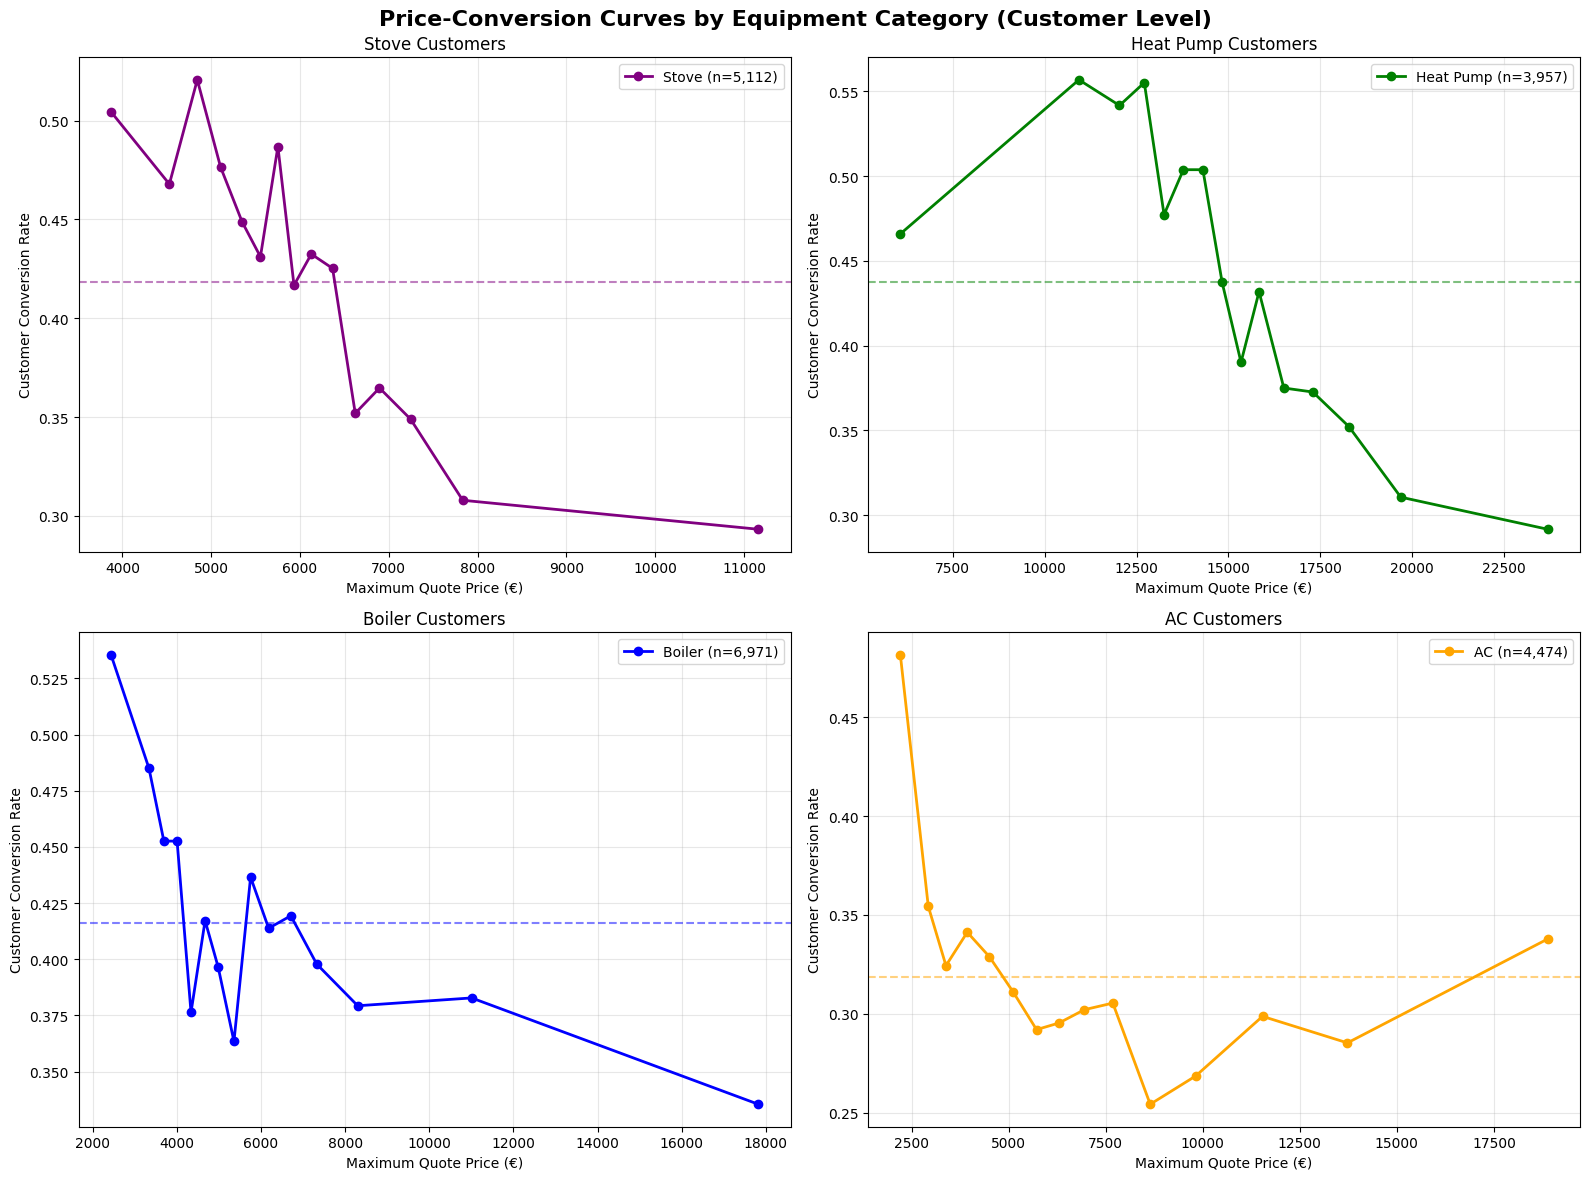


Conversion by Brand Price

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'MCZ', 'E.L.M. LEBLANC', 'FRISQUET', 'SAUNIER DUVAL', 'DE DIETRICH', 'HITACHI']


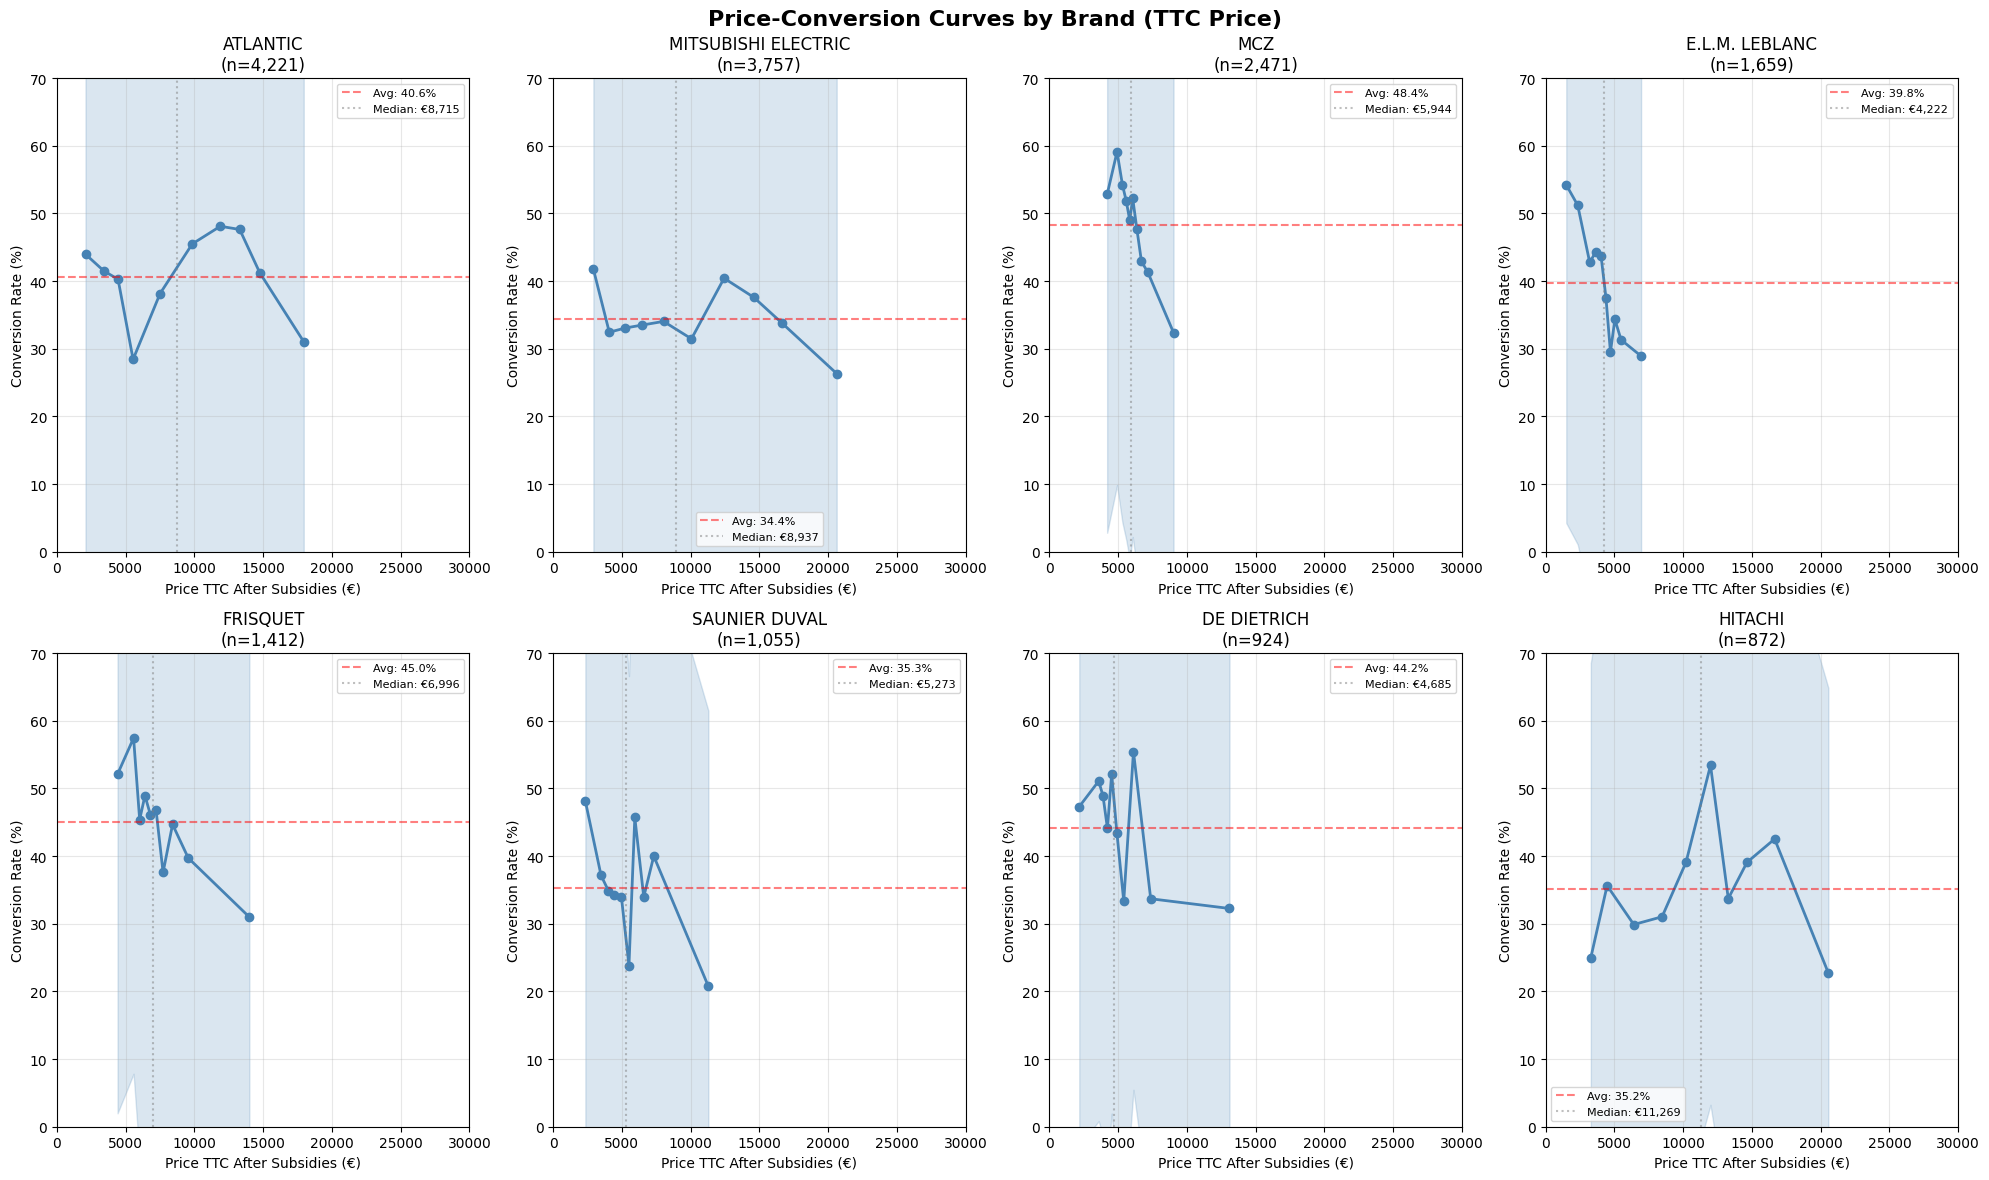


Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


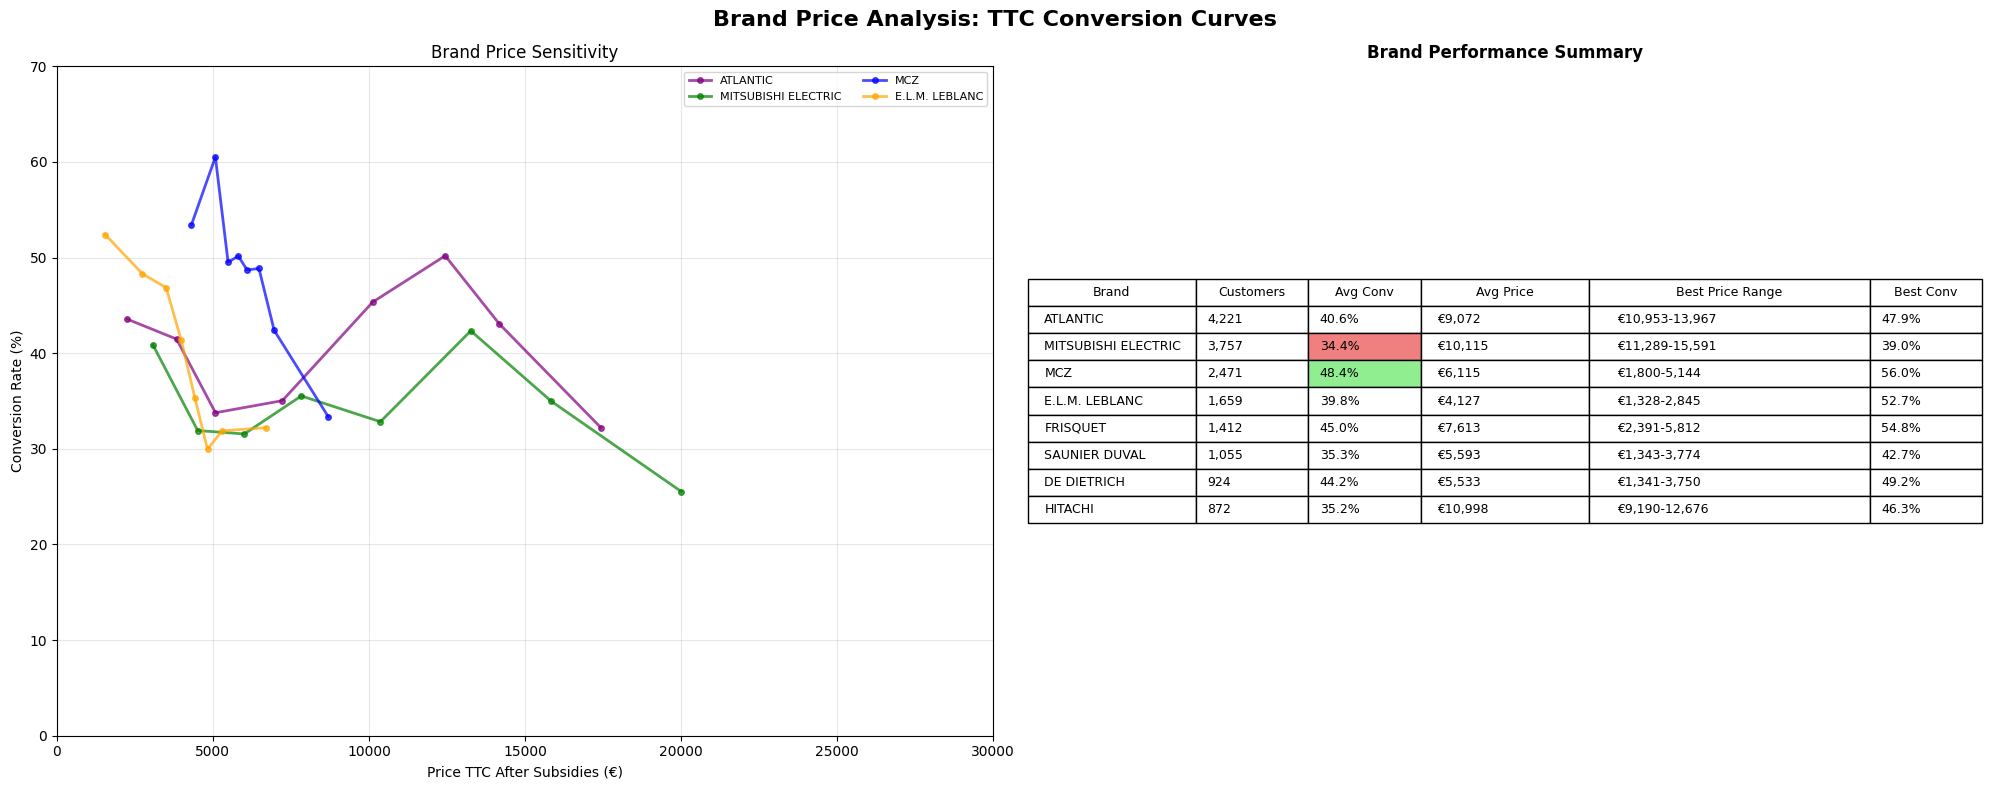


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'HITACHI', 'VIESSMANN', 'CHAPPEE']

Boiler - Top brands: ['E.L.M. LEBLANC', 'FRISQUET', 'SAUNIER DUVAL', 'ATLANTIC', 'DE DIETRICH', 'CHAPPEE']

Stove - Top brands: ['MCZ', 'DOVRE', 'JOLLY MEC', 'ORANIER', 'PALAZZETTI', 'Edilkamin']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC', 'HITACHI', 'DAIKIN', 'BOSCH', 'Unknown']


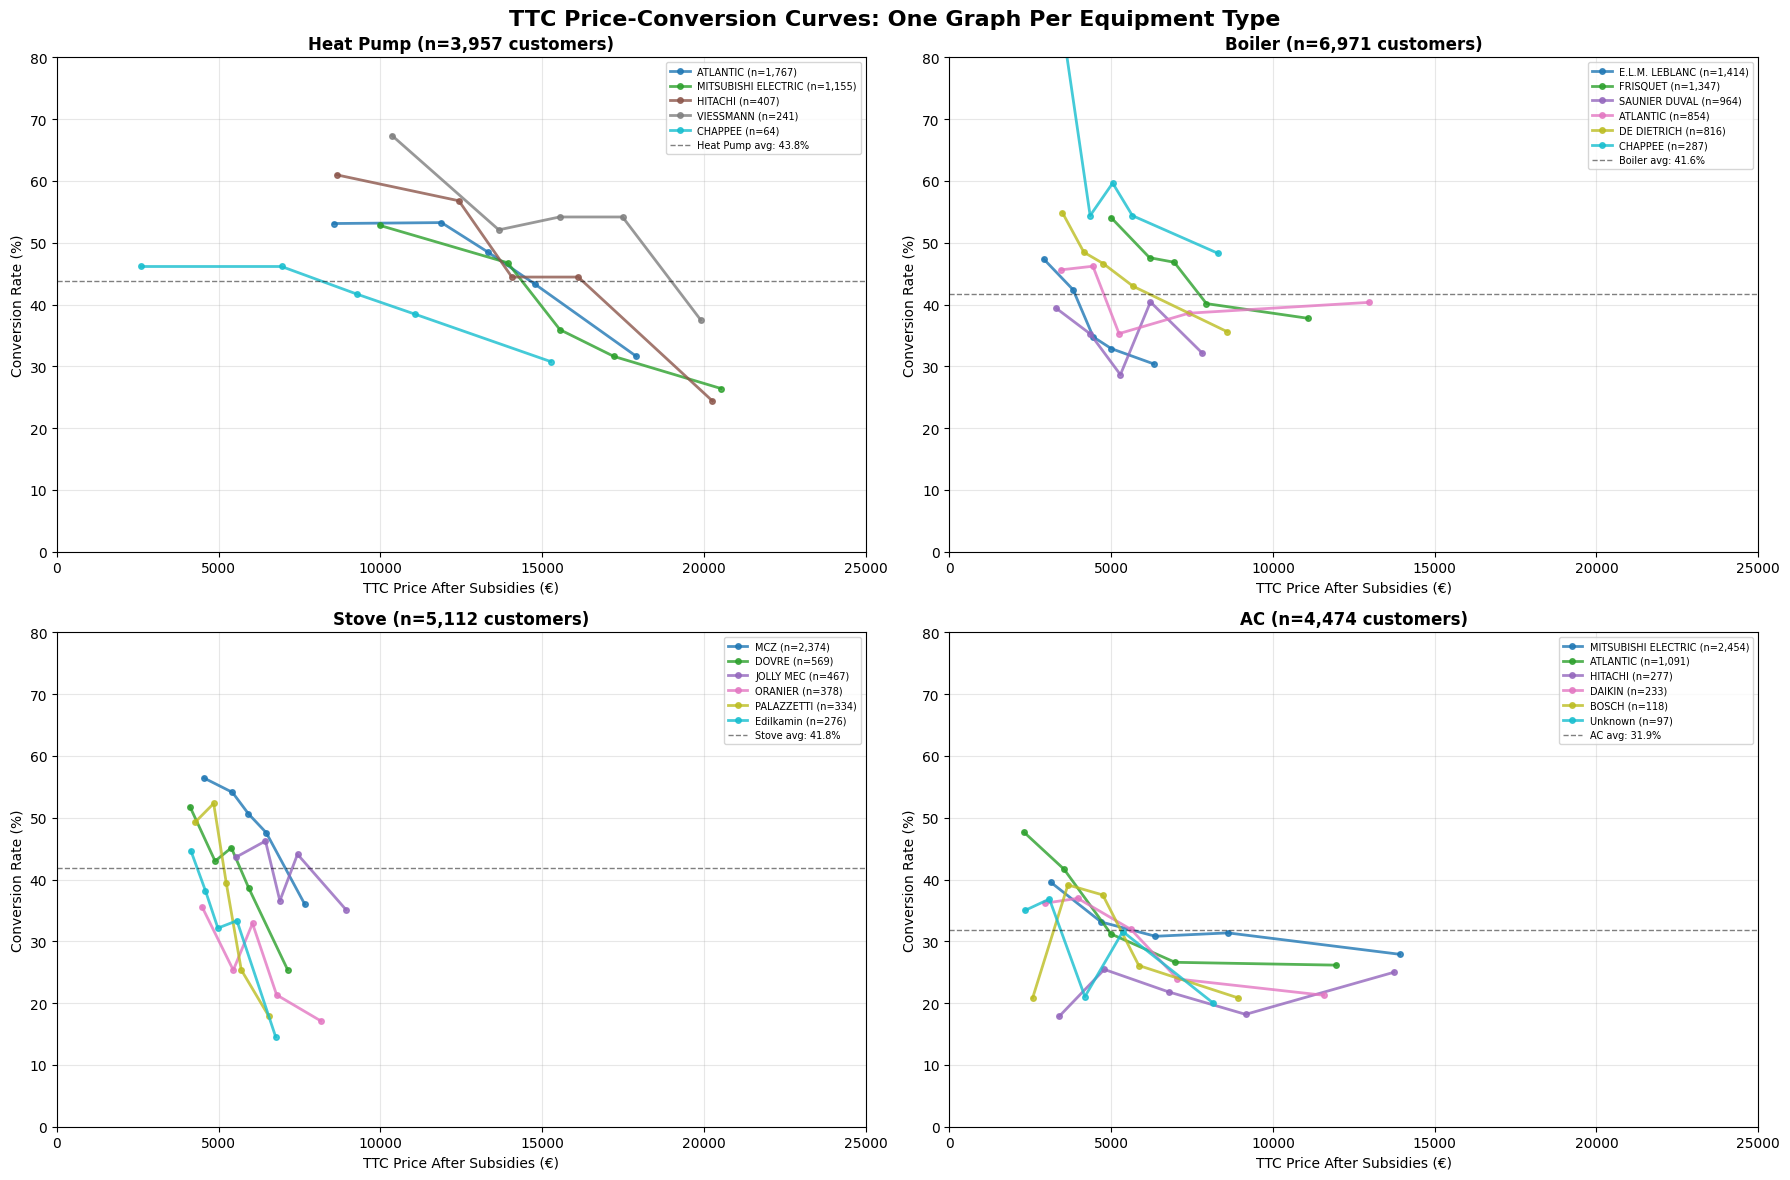

In [6]:
visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')


Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


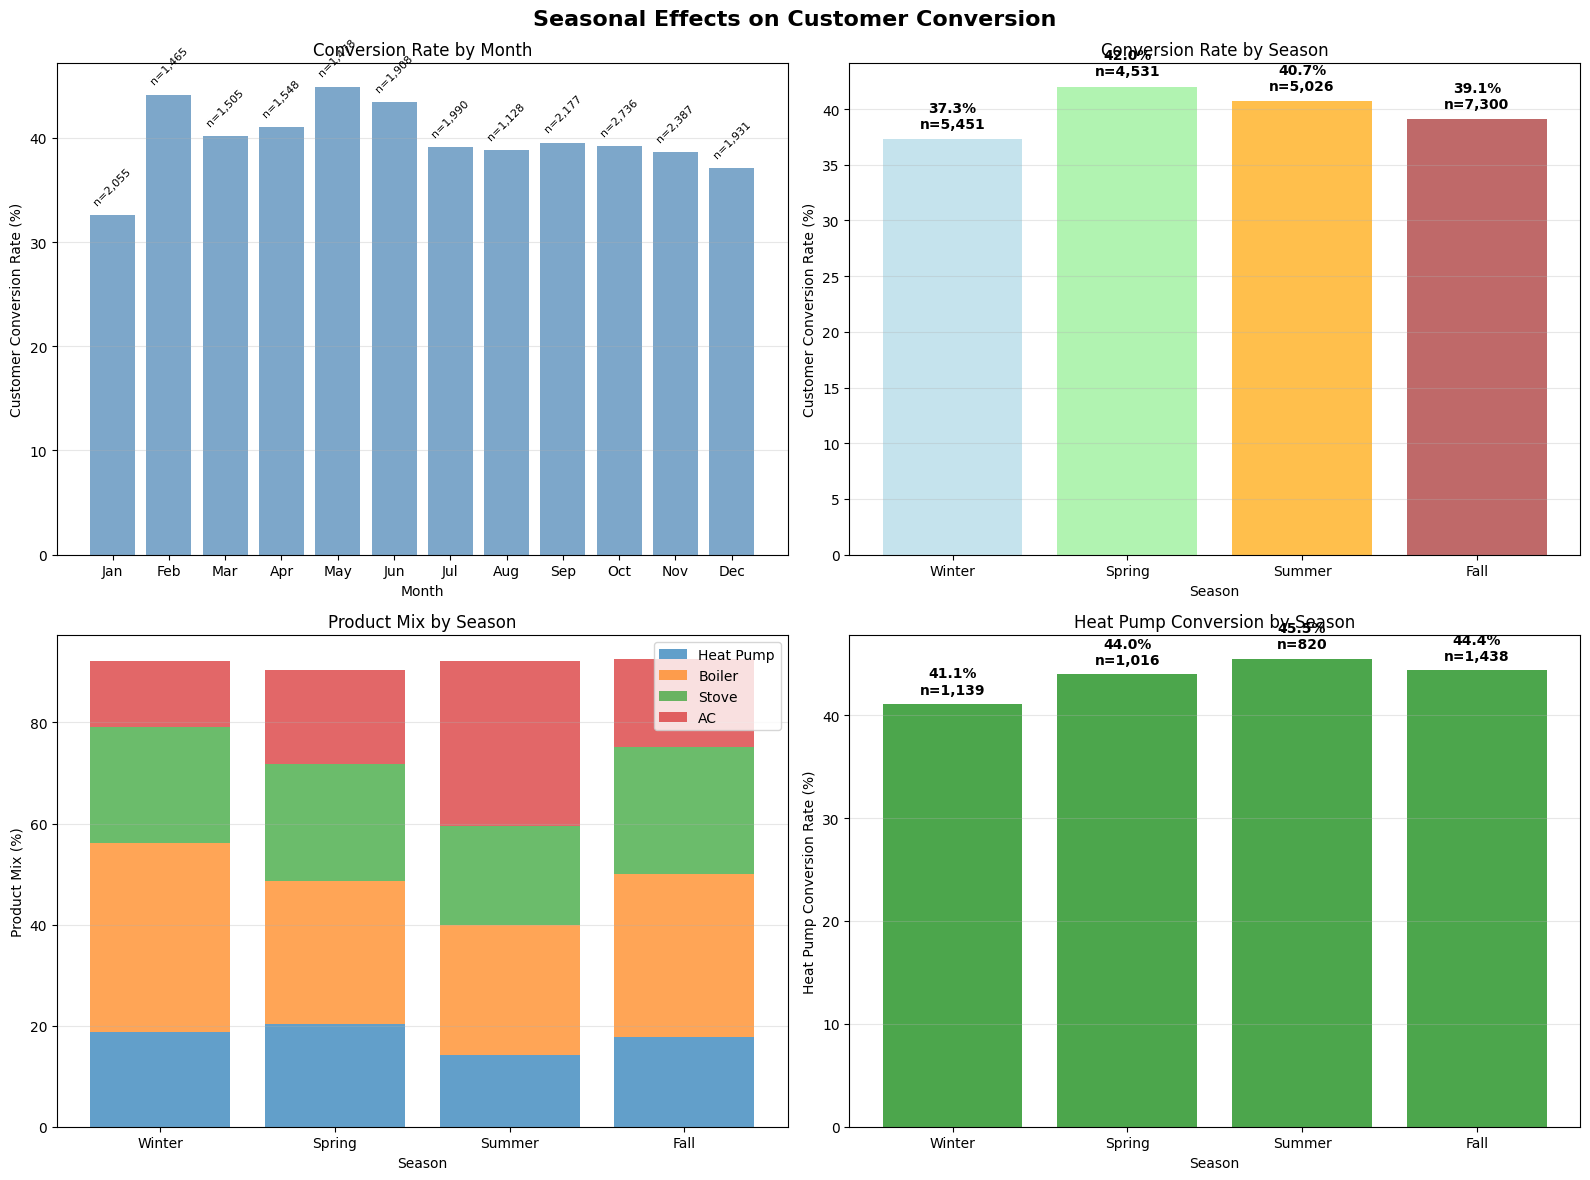


SEASONAL STATISTICS

Conversion by season:
  Winter: 37.3% (n=5,451)
  Spring: 42.0% (n=4,531)
  Summer: 40.7% (n=5,026)
  Fall: 39.1% (n=7,300)

Seasonality chi-square p-value: 0.000008
Statistically significant: YES

Regional Seasonal Pattern

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Top regions: ['Normandie', 'Auvergne-Rhône-Alpes', 'Île-de-France']


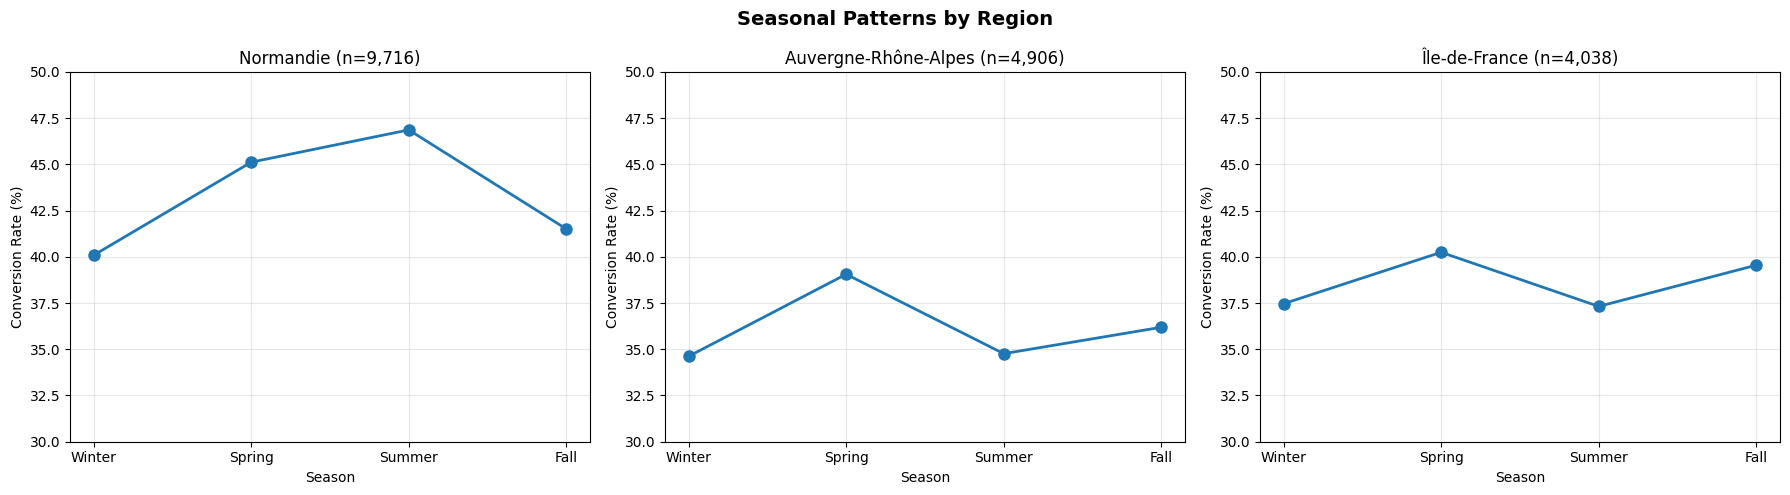

In [7]:
visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')


Year-over-year trends

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Quarterly conversion rates:
                  mean  count
year_quarter                 
2023Q1        0.534125    337
2023Q2        0.477994    977
2023Q3        0.442418   1042
2023Q4        0.406358   1730
2024Q1        0.414591   1686
2024Q2        0.443790   1868
2024Q3        0.405759   1910
2024Q4        0.419545   2548
2025Q1        0.395329   2398
2025Q2        0.398277   2089
2025Q3        0.359368   2343
2025Q4        0.338256   2776
2026Q1        0.157285    604


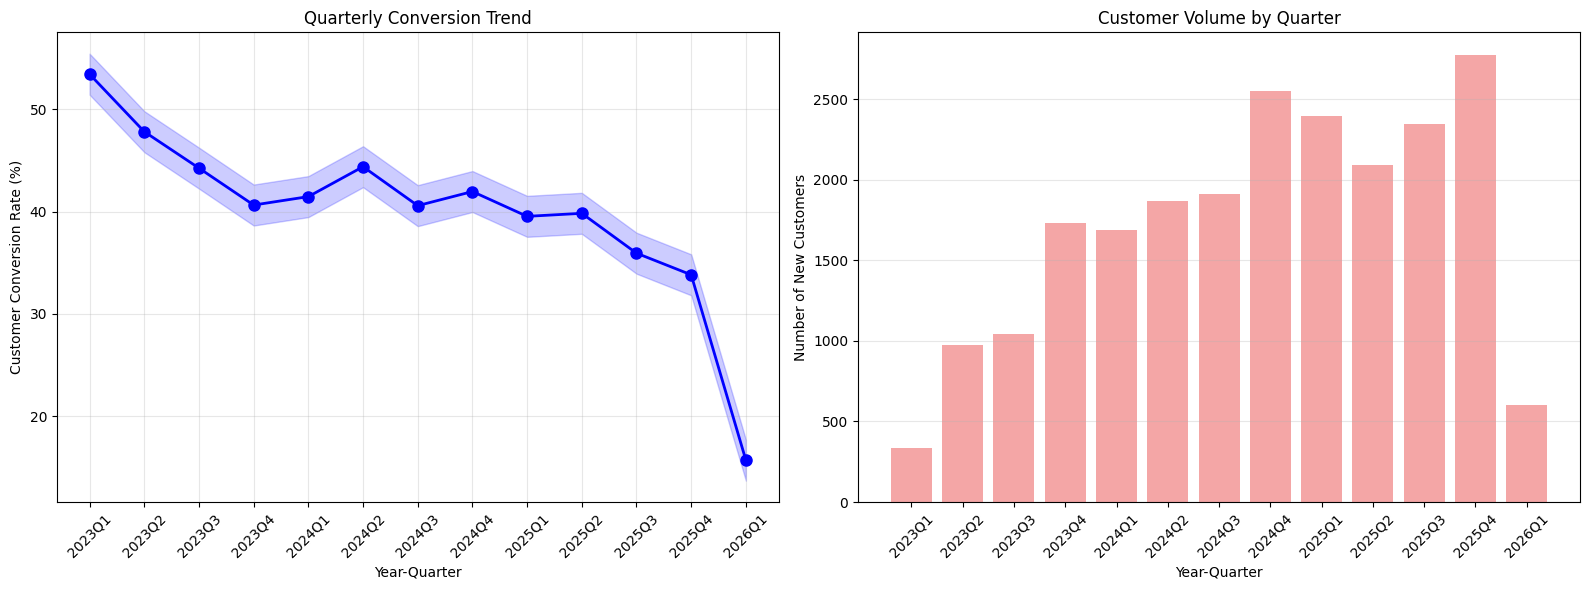


Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Best month: 5 (44.9%, n=1478)
Worst month: 1 (32.6%, n=2055)

Best season: Spring (42.0%)
Worst season: Winter (37.3%)

Suspension periods impact: 31.8% vs 40.8%
Difference: -9.0 points

Heat pump conversion by season:
  Winter: 41.1%
  Spring: 44.0%
  Summer: 45.5%
  Fall: 44.4%

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


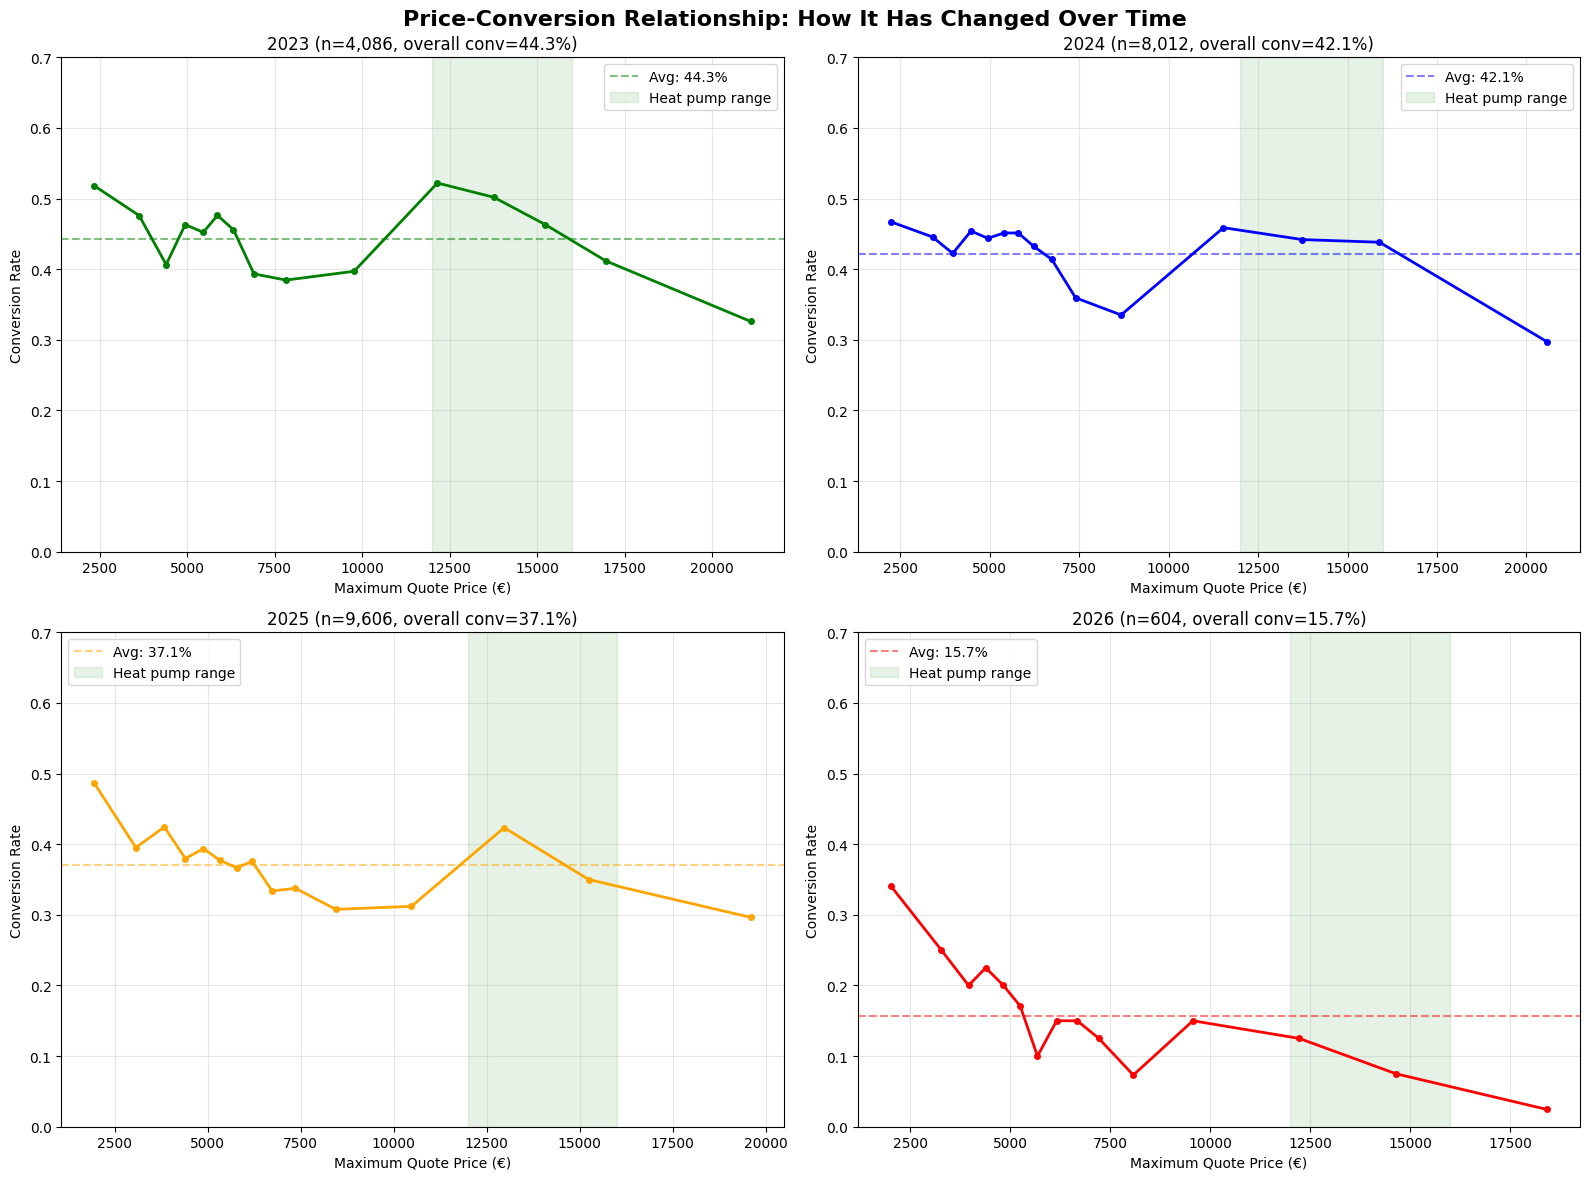


Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


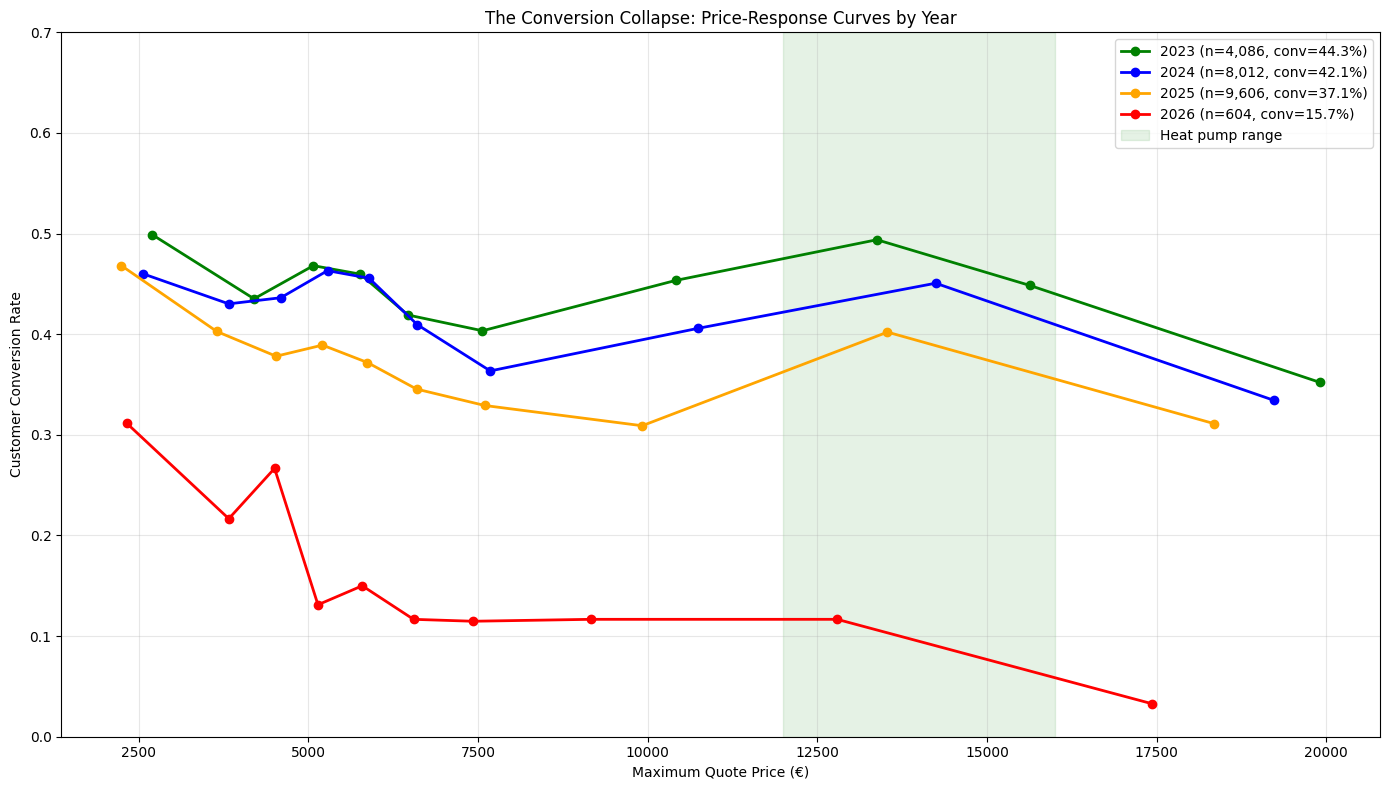


Sweet Spot Analysis Over Time

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Sweet spots by year (price points with conversion > avg + 3%):

2023 (overall avg: 44.3%):
  €2,077: 53.7% (n=205)
  €3,920: 48.1% (n=210)
  €11,395: 49.5% (n=204)
  €12,798: 49.0% (n=204)
  €13,954: 49.8% (n=205)

2024 (overall avg: 42.1%):
  €1,991: 48.9% (n=401)
  €5,118: 49.5% (n=400)
  €6,041: 46.9% (n=401)
  €11,950: 47.8% (n=400)
  €14,988: 48.2% (n=400)

2025 (overall avg: 37.1%):
  €1,774: 50.3% (n=481)
  €2,712: 43.3% (n=480)
  €3,910: 43.3% (n=480)
  €5,041: 42.1% (n=480)
  €12,704: 42.5% (n=480)


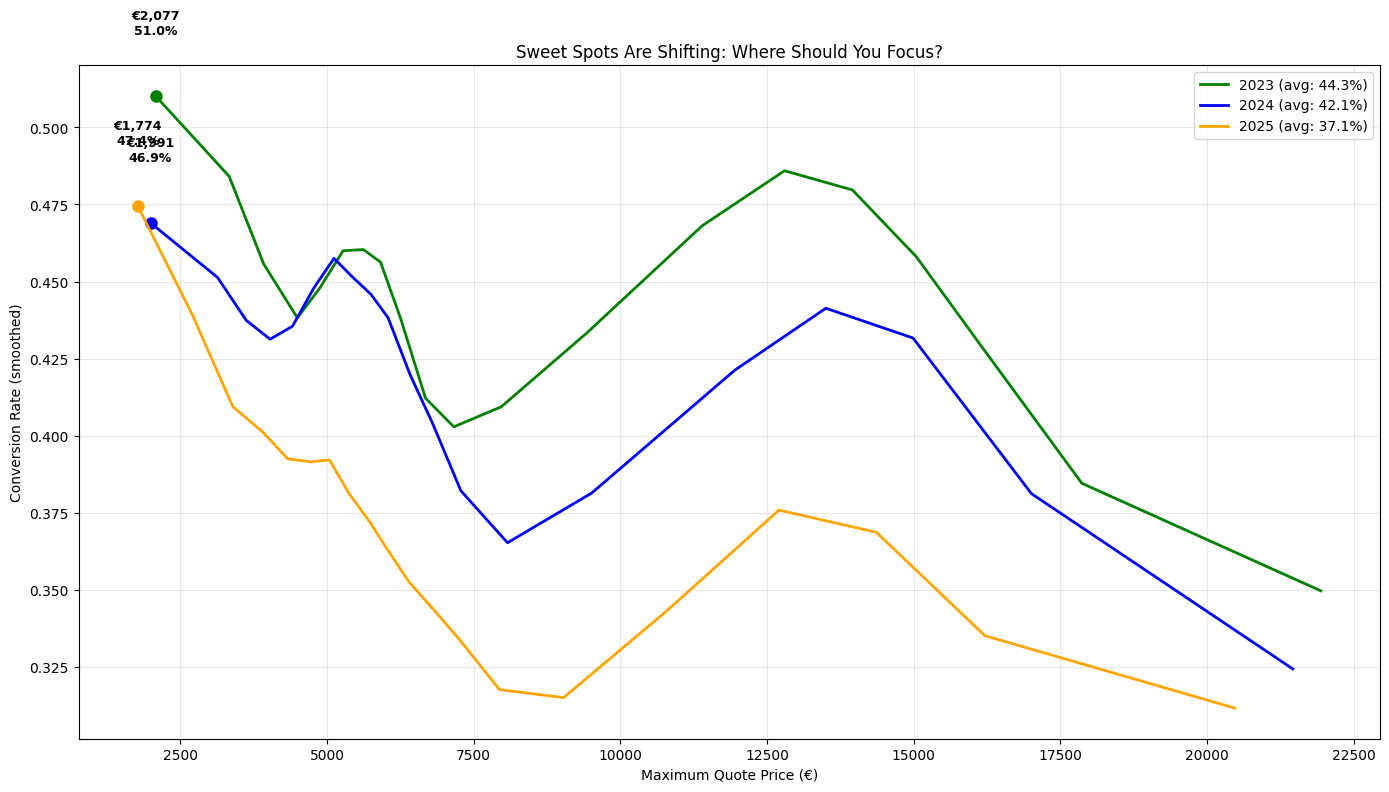


Administrative Uncertainty Effect

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Decision time distribution:
count    22308.000000
mean        20.289851
std         86.447456
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       1082.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 18,603 (83.4%)


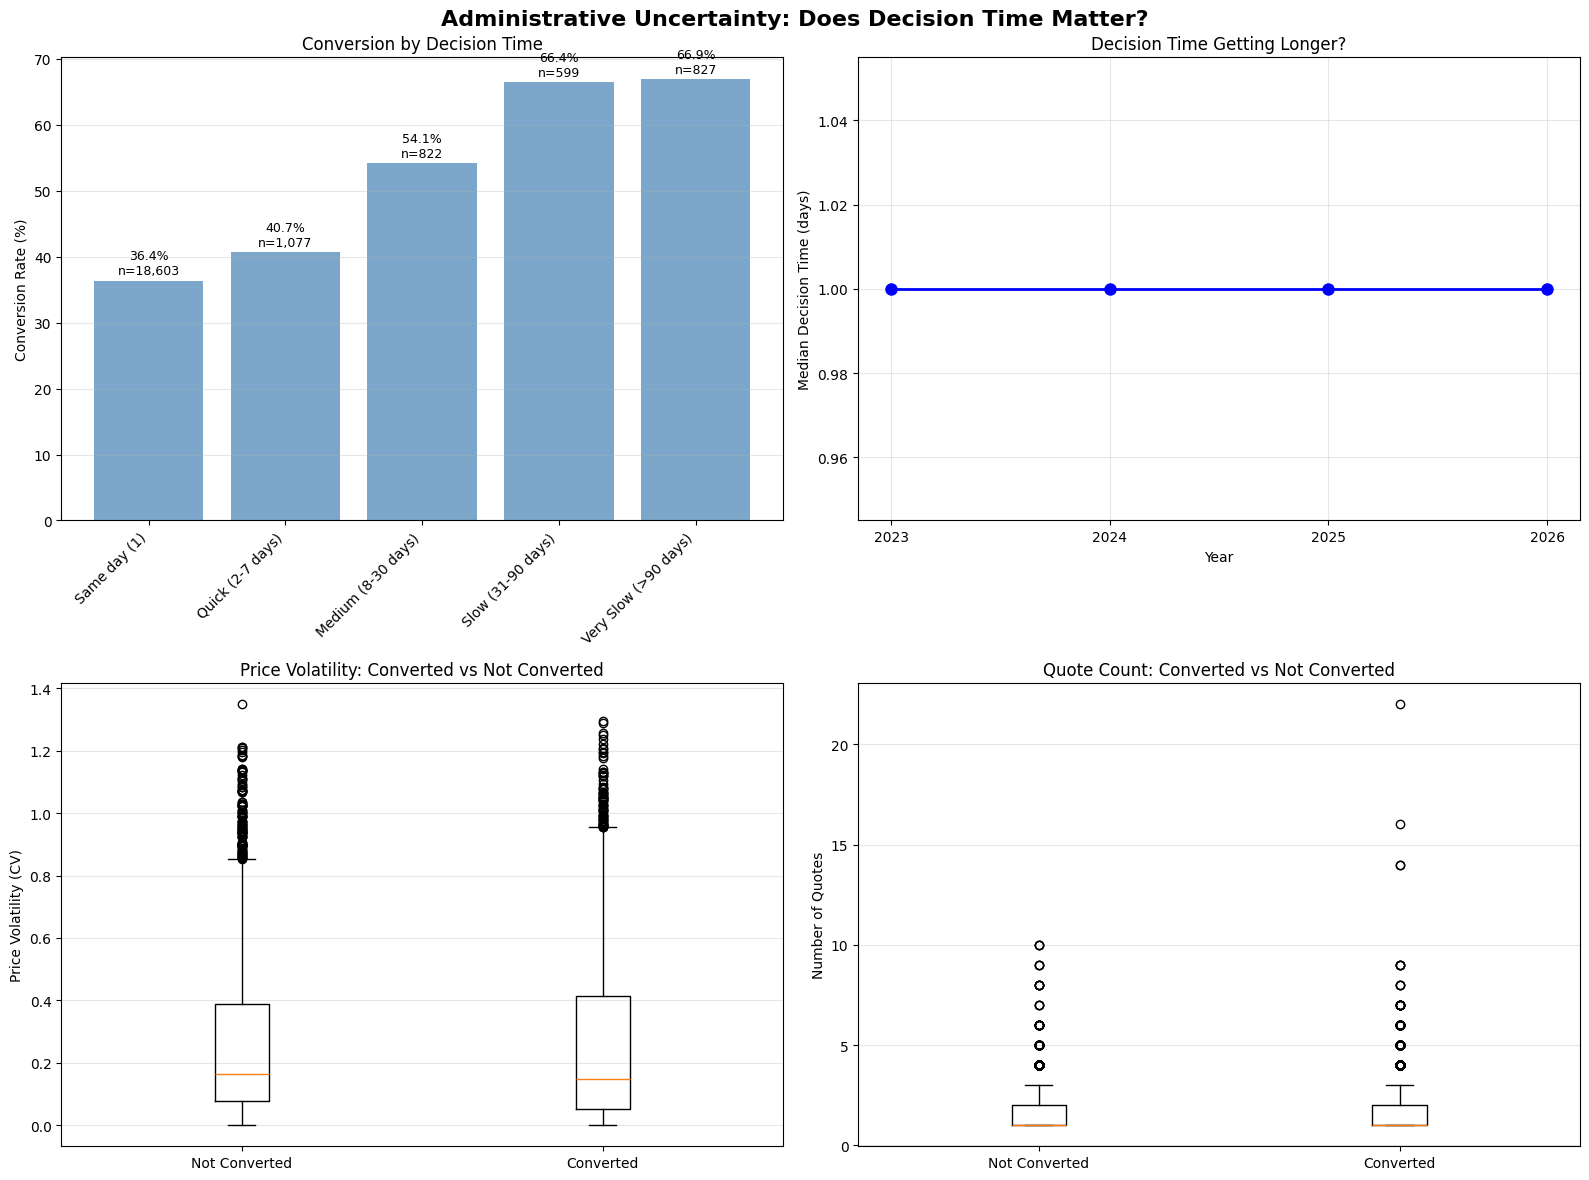


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1086.579, 4209.46]  (4209.46, 5653.482]  \
main_equipment_category                                             
AC                                 37.541806            32.258065   
Boiler                             48.332478            38.848548   
Heat Pump                          48.888889            58.536585   
Other                              43.972999            26.262626   
Stove                              49.090909            47.281993   
Unknown                            57.142857            60.000000   

price_bin_simple         (5653.482, 7188.172]  (7188.172, 12990.276]  \
main_equipment_category                                                
AC                                  29.127517              28.012279   
Boiler                              42.458101              38.171141   
Heat Pump                           28.000000              54.565953   
Other                     

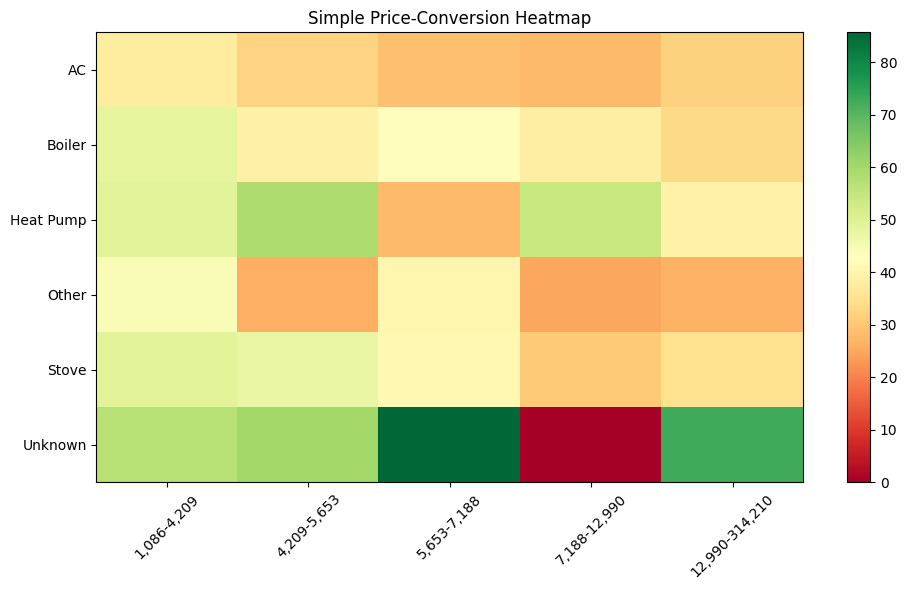


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire                  103
Emetteur de chauffage  ou chappe      93
Produit VMC                           89
Unknown                               36
Fumisterie                            13
Name: count, dtype: int64

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321


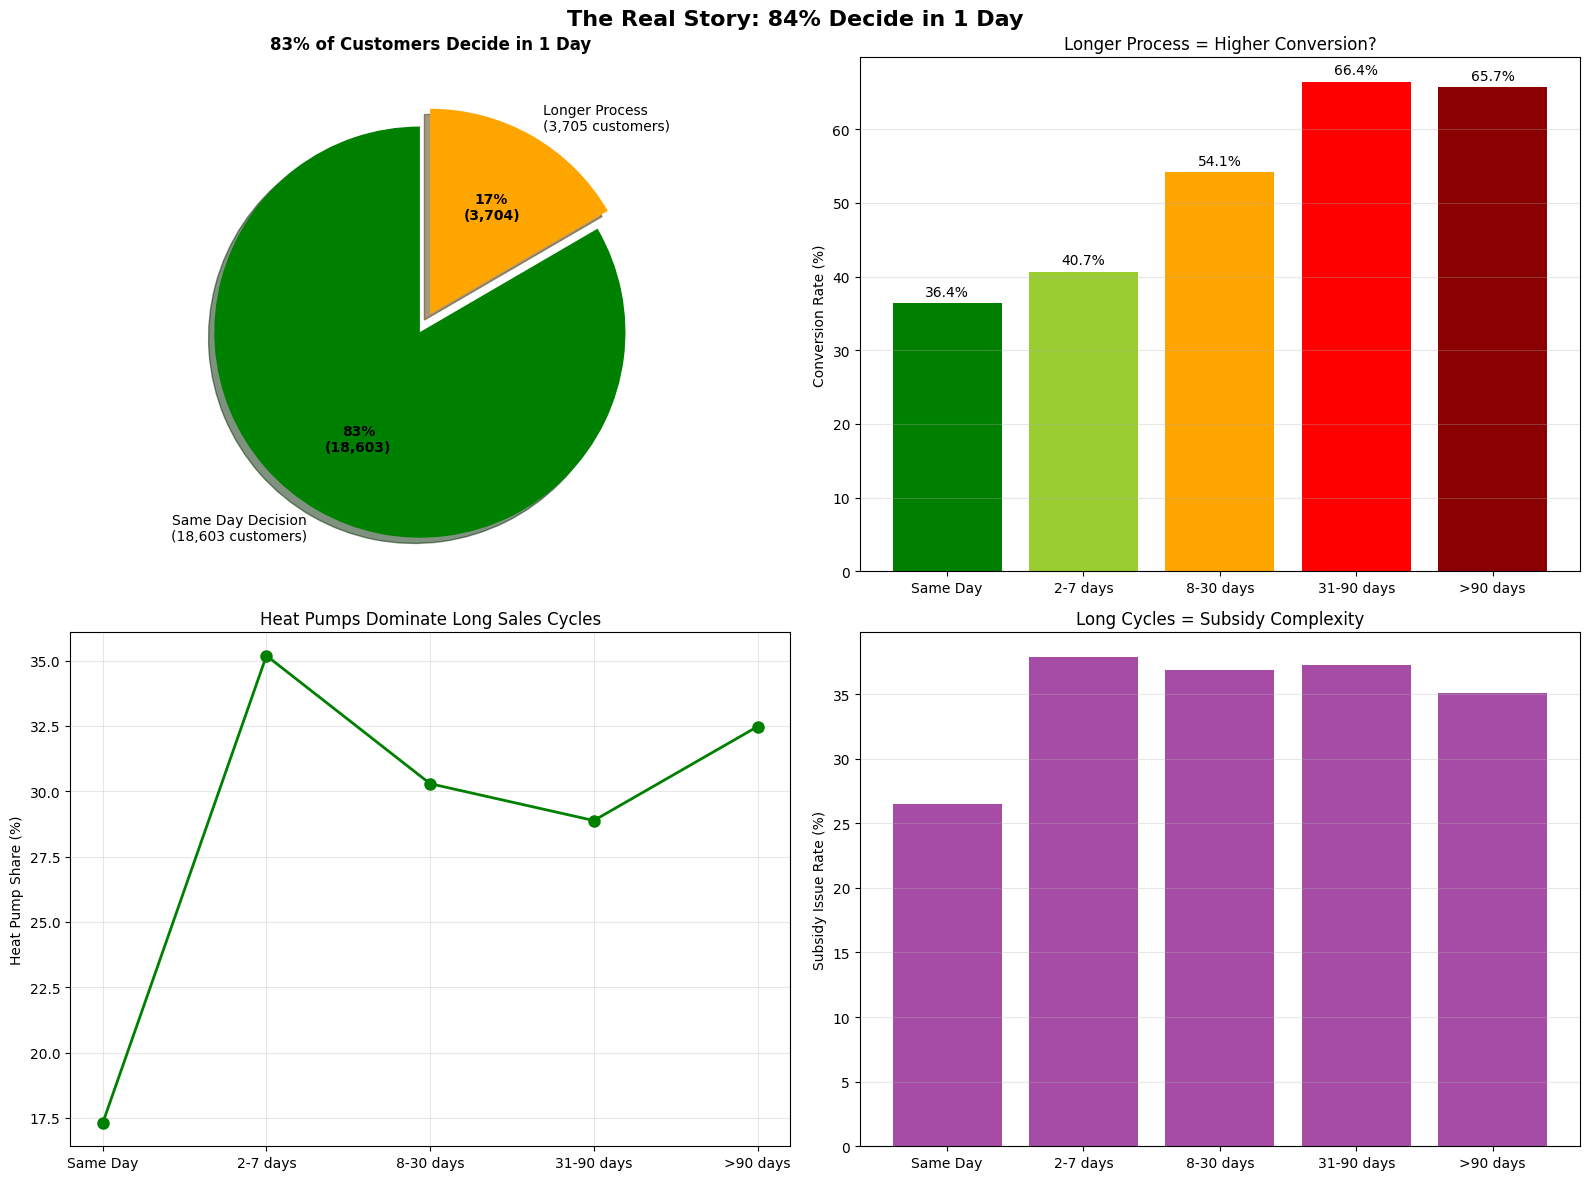

In [8]:
visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')


Heat Pump Performance Over Time

Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2023              0.480            1151  14760.547               0.700
2024              0.459            1506  15021.693               0.663
2025              0.405            1656  15145.143               0.754
2026              0.100             100  14783.915               0.750


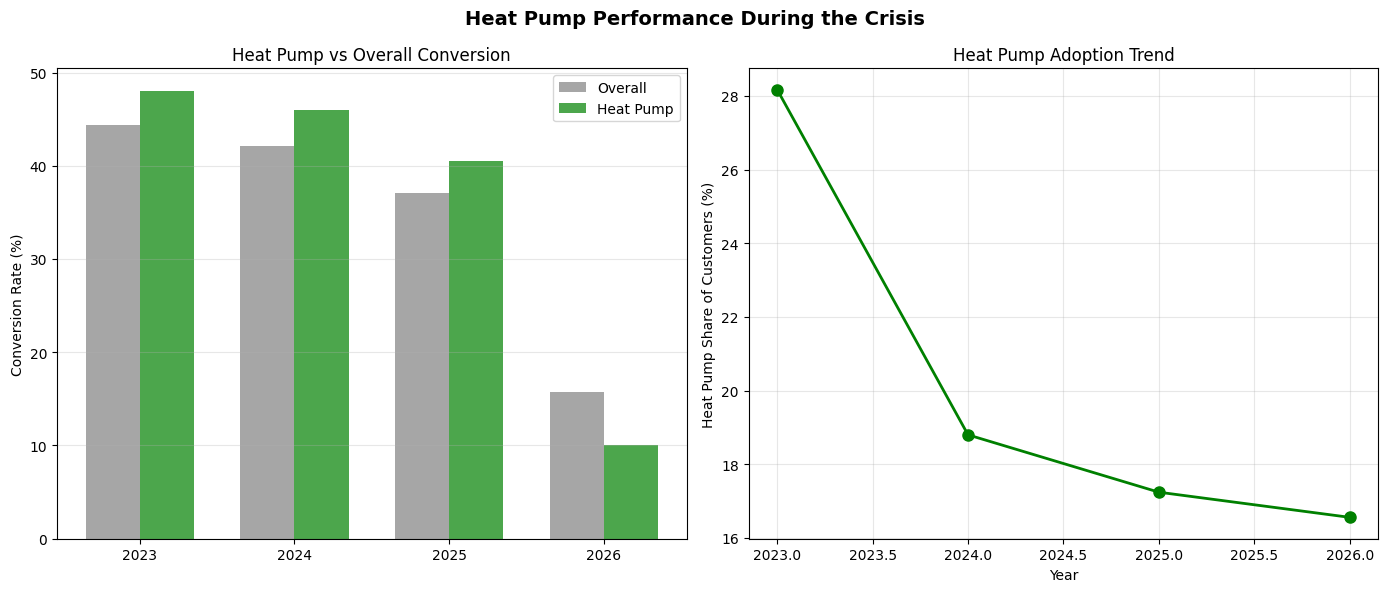

In [9]:
visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')


Analyzing 22,308 customers
Price range: €1,339 to €28,212
Median price: €6,321

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €1.6k (48.8%) and €2.5k (48.4%)
Dead zone: €19.4k-28.2k (28-37%)
Heat pumps: 71% subsidy issues, 43.6% conversion
Price sensitivity: Heat Pump (20.3pts) > Stove (16.4pts) > Boiler (11.6pts) > AC (8.2pts)
Same day decisions: 83%


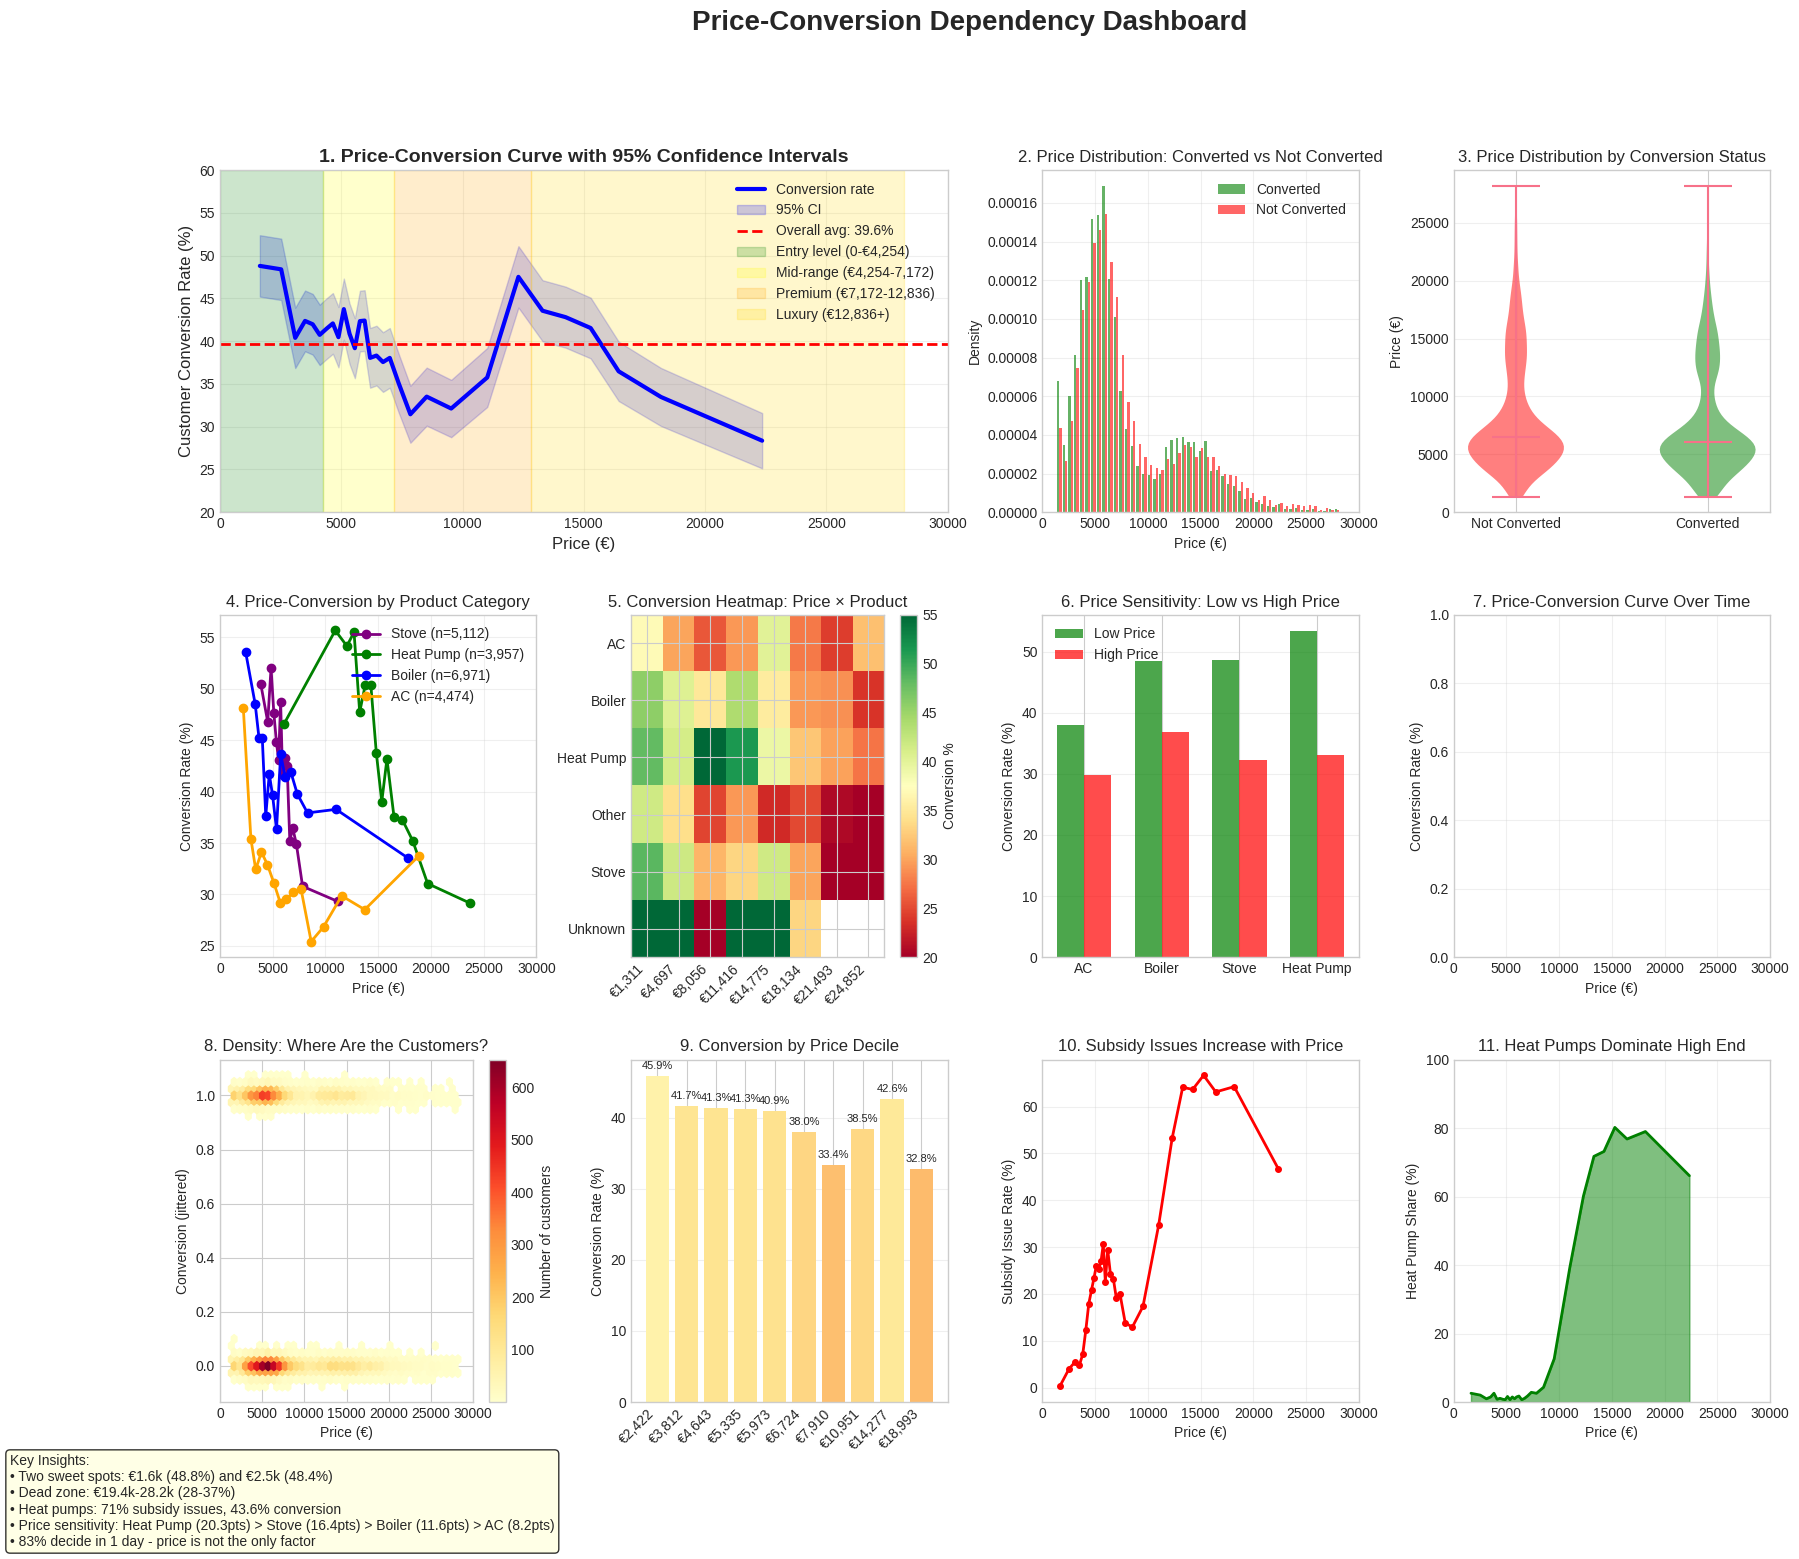

In [10]:
show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

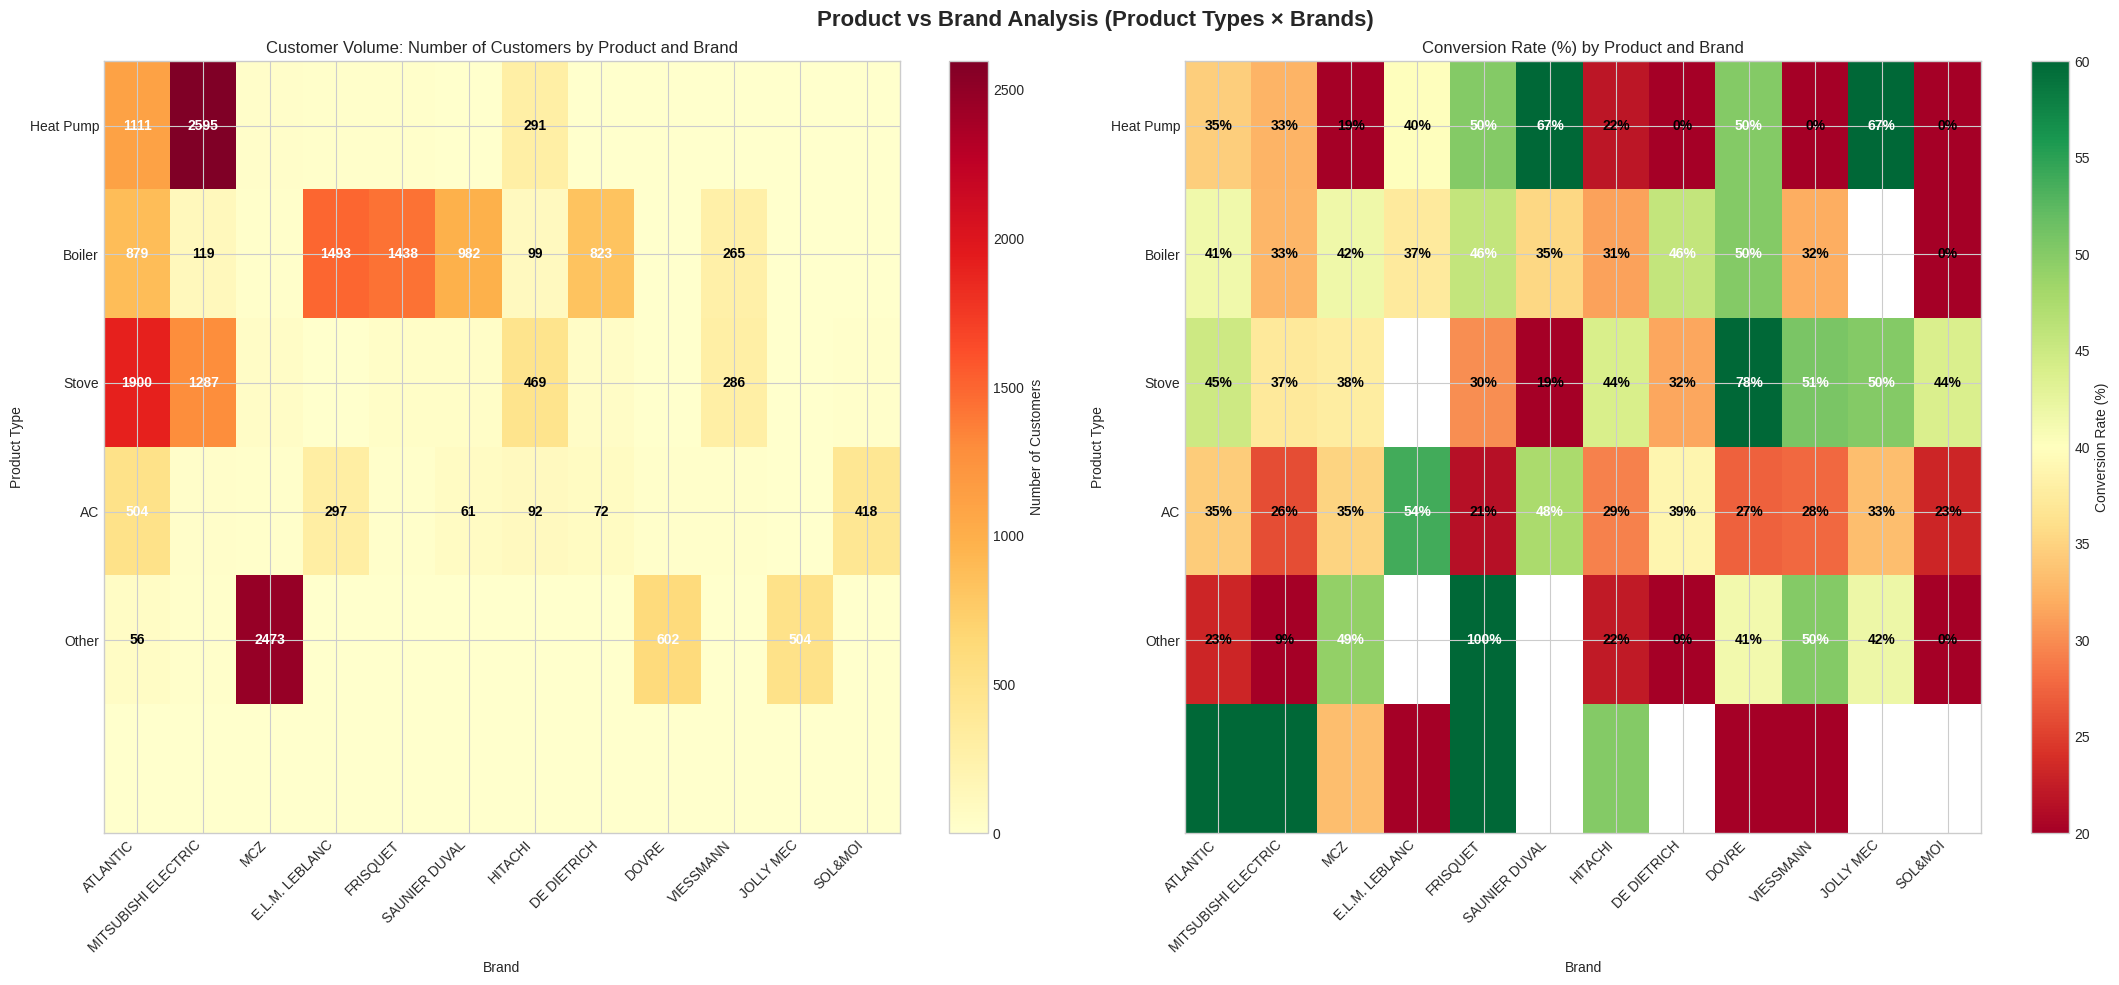


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC   MCZ  E.L.M. LEBLANC  FRISQUET  SAUNIER DUVAL  HITACHI  DE DIETRICH  DOVRE  VIESSMANN  JOLLY MEC  SOL&MOI
main_equipment_category                                                                                                                                          
AC                           1111                 2595    21              15        16              9      291            5      2          3          3        1
Boiler                        879                  119    12            1493      1438            982       99          823      6        265          0        2
Heat Pump                    1900                 1287    45               0        40             32      469           41      9        286          2       16
Other                         504        

In [11]:
show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)